# **Week 1 exploration notebook** 
Date: 2025-07-06 \
Objectives: 
- implement simple Bayesian
- MCMC with random sampling
- SBI explorations


**Simple Bayesian application** \
scenario: test for a disease, with prior p(carrier) = some value between 0 and 1 

likelihood (accuracy of the testing positive) p(positive | carrier) = 0.95 \
marginal p(positive) = p(positive | carrier) * p(carrier) + p(positive | non-carrier) * p(non-carrier) \
                     = likelihood * prior + (1 - likehood) * (1 - prior) 

Bayes theorem: posterior p(carrier | positive) = likelihood * prior / marginal

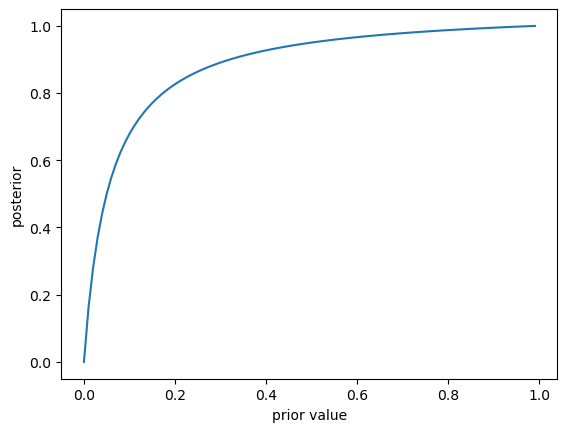

In [132]:
import numpy as np
import matplotlib.pyplot as plt

def posterior_est(likelihood, prior):
    marginal = likelihood * prior + (1 - likelihood)*(1-prior)
    posterior = likelihood * prior / marginal
    return posterior

likelihood = 0.95
prior = np.arange(0,1, 0.01)

plt.plot(prior, posterior_est(likelihood, prior))
plt.xlabel('prior value')
plt.ylabel('posterior')
plt.show()

It is clear from the plot that with a stong prior, a strong posterior is produced, in this scenario it means that if there is a high carrier density then the posterior, probability of the person being a carrier given they are tested positive, is also high. On the other hand if carrier density is low, then being tested positive does not strongly imply the person is a carrier, i.e. the test itself could be quite unreliable compared to the carrier density.

**Gaussian likelihood, uniform prior** \
Now I'd like to try implement a simple 1D Gaussian on this example, where the log_prior is uniformly distributed and likelihood ~ $N(0.9, 0.1^2)$. $\mu$ will be some value between 0 and 1.

[ -669.08801305 -1332.56149222 -1869.63630103 -2388.56024687
 -2828.25467083 -3235.07702117 -3572.80135117 -3836.01147407
 -4051.68689738 -4217.85549943 -4368.0540651  -4483.63985094
 -4559.87598281 -4607.84967329 -4635.61335868 -4650.14462049
 -4657.96448469 -4666.03856716 -4678.19178596 -4698.35504477]


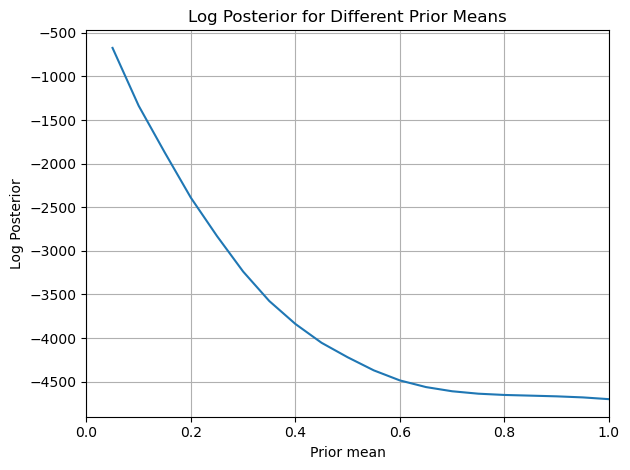

In [140]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(13)

prior_mu = np.arange(0.05,1.05,0.05)  #take 0.05 steps for prior mean
prior_sd = 0.1   #changed from 0.05 

likelihood_mu = 0.9
likelihood_sd = 0.1 #changed from 0.05

#Samples with different mu values of prior
samples = [np.random.normal(loc=mu, scale=prior_sd, size=20) for mu in prior_mu]
#samples[i] row corresponds to data simulated with the ith value of prior_mu

def log_likelihood(samples, likelihood_mu, likelihood_sd):
    log_like, ll = [], []

    for data in samples:
        ll.append( -(data - likelihood_mu)**2 / (2*likelihood_sd**2))   #add likelihood of each data point to ll array
        log_like.append(np.sum(ll))  #each index of log_likelihood logs the sum of ll array
    return np.array(log_like)
print(log_likelihood(samples, likelihood_mu, likelihood_sd))

#Gaussian prior
# def log_prior():
#     return np.array([-0.5 * mu / (2*prior_sd**2) for mu in prior_mu])  

#uniform prior
log_prior = np.log(1/len(prior_mu))


# Results
log_posteriors = log_likelihood(samples, likelihood_mu, likelihood_sd) + log_prior
#ignore evidence which is just an additive constant

plt.figure()
plt.plot(prior_mu, log_posteriors)

plt.xlabel('Prior mean')
plt.ylabel('Log Posterior')
plt.xlim(0,1)
plt.title('Log Posterior for Different Prior Means')
plt.grid(True)
plt.tight_layout()
plt.show()

Here i took the uniform distribution of prior means being equal probability of obtaining each of the prior_mu values, while likelihood is Gaussian distributed then plotted the log(posterior) values at each of the prior mean values, i.e. the plot shows $P(\mu | samples)$ against $\mu$. 
**The output seem to suggest prior means close to 0 gives the largest posterior?**


**Posterior odds ratio**\
consider the posterior odds ratio (OR) of two different prior choices, e.g. p1(carrier) = 0.05 and p2(carrier) = 0.10, where the posterior OR represents by what factor is one more likely to have a true positive result (carries the disease given tested positive).\
The posterior OR is defined as P(carrier 1 | positive) / P(carrier 2 | positive)

In [134]:
# simply compare the two priors
likelihood_1, likelihood_2 = 0.95, 0.95 #here assume the same likelihood since the same test is being carried out
prior_1 = 0.05
prior_2= 0.10

OR = likelihood_1 * prior_1 / (likelihood_2 * prior_2)
print(f'the posterior odds ratio for prior 1 =',prior_1, 'and prior 2 =', prior_2, 'is', OR, '\n'
      'meaning that carrier probability of',prior_1, 'is', OR, 'times more likely to be tested positve correctly than carrier probabiltity of', prior_2)

the posterior odds ratio for prior 1 = 0.05 and prior 2 = 0.1 is 0.5 
meaning that carrier probability of 0.05 is 0.5 times more likely to be tested positve correctly than carrier probabiltity of 0.1


posterior OR is useful in comparing the accuracy and finding the association between observed data (positive tests) and parameters (being a carrier), with different conditions (e.g. different tests for different prior distributions or other extra parameters associated with each prior) further investigations can be done to possibly find correlations between those parameters based on their association with certain parameters.

**MCMC (Metropolis-Hasting) with random sampling**\
Here consider a Gaussian randomly sampled for MCMC algo

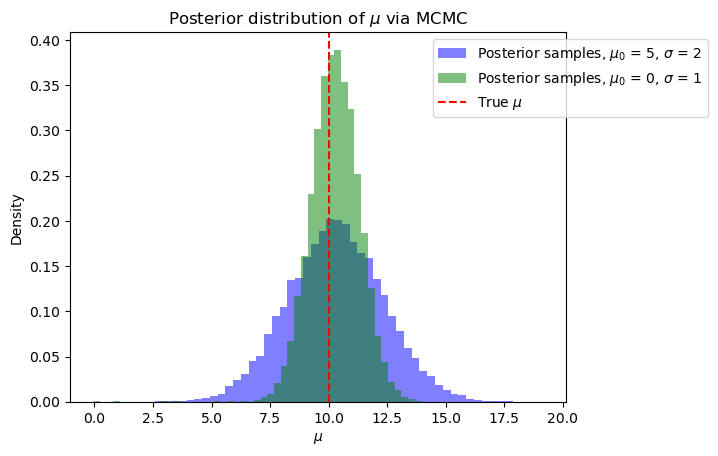

In [135]:
np.random.seed(13)

true_mean = 10
sigma = 2
#draw random data from the Gaussian
data = np.random.normal(true_mean, sigma, size=50)   

#Gaussian distributed prior
def log_prior(mean, sd):
    return (- mean / (2*sd**2))

#Gaussian distributed likelihood, as a sum of each individual data point
def log_likelihood(mean, sd, data):
    return np.sum( -(mean-data)**2 / (2*sd**2))

#log_posterior as a function of log_prior and log_likelihood
def log_posterior(mean, sd, data):
    return log_prior(mean, sd) + log_likelihood(mean,sd,data)

#MH MCMC
def MH(init_mean, sd, data, iteration, log_posterior):
    sample = []  #initialise empty set to store iterated data
    mu = init_mean #set the initial mean value

    for _ in range(iteration):
        prop_mean = np.random.normal(mu, sd)  #draw a proposal mean from the initial mean distribution
        #construct MH accptance ratio from the proposal mean and the initial mean
        log_accept_ratio = log_posterior(prop_mean, sd, data) - log_posterior(mu, sd, data)  

        #accept the proposal mean if a randomly generated probability is smaller than the log_accept_ratio, 
        #ie the proposal mean gives a higher posterior than the initial mean
        if log_accept_ratio > np.log(np.random.rand()):
            mu = prop_mean
        sample.append(prop_mean)

    return np.array(sample)

#insert some initial conditions for the MH iteration
init_mean1 = 5
sd1 = 2
iteration = 20000

samples1 = MH(init_mean1, sd1, data, iteration, log_posterior)
burn_in = 1000
samples1 = samples1[burn_in:]

init_mean2 = 0
sd2 = 1
samples2 = MH(init_mean2, sd2, data, iteration, log_posterior)

plt.hist(samples1, bins=50, density=True, label='Posterior samples, $\mu_0$ = 5, $\sigma$ = 2', color='blue', alpha = 0.5)
plt.hist(samples2, bins=50, density=True, label='Posterior samples, $\mu_0$ = 0, $\sigma$ = 1', color='green', alpha = 0.5)
plt.axvline(true_mean, label='True $\mu$', color='red', linestyle='--')

plt.xlabel("$\mu$")
plt.ylabel("Density")
plt.title("Posterior distribution of $\mu$ via MCMC")
plt.legend(loc='upper right', bbox_to_anchor = (1.3,1))
plt.show()

It's clear from the histogram that both initial mean and standard deviation values converged quite well to the tru mean value and the resultant histograms resemble Gaussian distributions with widths approximately equal to standard deviations of the initial means.

**SBI lib exploration**

following the official sbi documentation

In [136]:
import sbi
import sbibm
import torch
import numpy as np 
import matplotlib.pyplot as plt

# print(f"PyTorch version: {torch.__version__}")
# print(f"SBI version: {sbi.__version__}")

from sbi.analysis import pairplot
from sbi.inference import SNPE      #somehow I can't import NPE but SNPE works
from sbi.utils import BoxUniform
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)

num_dim = 3

#simulator function adds 1.0 and a random Gaussian noise to the input
def simulator(theta):
    return theta + 1.0 + torch.randn_like(theta) * 0.1

prior = BoxUniform(low=-2 * torch.ones(num_dim), high=2 * torch.ones(num_dim))

# Check prior, return PyTorch prior.
prior, num_parameters, prior_returns_numpy = process_prior(prior)
# Check simulator, returns PyTorch simulator able to simulate batches.
simulator = process_simulator(simulator, prior, prior_returns_numpy)
# Consistency check after making ready for sbi.
check_sbi_inputs(simulator, prior)

#Check prior, return PyTorch prior. \
prior, num_parameters, prior_returns_numpy = process_prior(prior) \
#Check simulator, returns PyTorch simulator able to simulate batches. \
simulator = process_simulator(simulator, prior, prior_returns_numpy) \
#Consistency check after making ready for sbi. \
check_sbi_inputs(simulator, prior) 

#or use a more compact function, where process_simulator and process_prior are internally called, \
#and prepares the data in the same way as above, into tensor forms, match dimensionality etc. \
#simulator, prior = prepare_for_sbi(simulator, prior)

In [137]:
inference = SNPE(prior=prior)

num_simulations = 2000
theta = prior.sample((num_simulations,))
x = simulator(theta)

#these functions are internally called in the simulate_for_sbi(simulator, prior, num_simulations=) function, so can be combined into the same line
#such that
#theta, x = simulate_for_sbi(simulator, prior, num_simulations=2000)

# #check tensor size
# print("theta.shape", theta.shape, theta.dtype)
# print("x.shape", x.shape, x.dtype)

inference = inference.append_simulations(theta, x)

#train density estimator
density_estimator = inference.train()

posterior = inference.build_posterior(density_estimator)
print(posterior) # prints how the posterior was trained

 Neural network successfully converged after 89 epochs.Posterior conditional density p(θ|x) of type DirectPosterior. It samples the posterior network and rejects samples that
            lie outside of the prior bounds.


Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

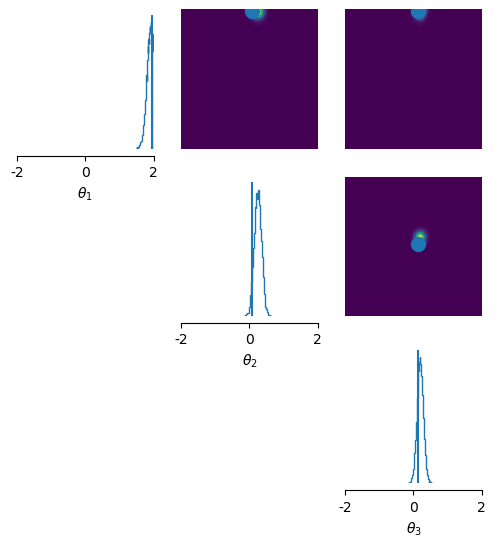

In [138]:
#visualisation
theta_true = prior.sample((1,))
# generate our observation
x_obs = simulator(theta_true)

samples = posterior.sample((10000,), x=x_obs)
_ = pairplot(samples,
             points=theta_true,
             limits=[[-2, 2], [-2, 2], [-2, 2]],
             figsize=(6, 6),
             labels=[r"$\theta_1$", r"$\theta_2$", r"$\theta_3$"])

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

(<Figure size 600x600 with 9 Axes>,
 array([[<Axes: xlabel='$x_1$'>, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: xlabel='$x_2$'>, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: xlabel='$x_3$'>]], dtype=object))

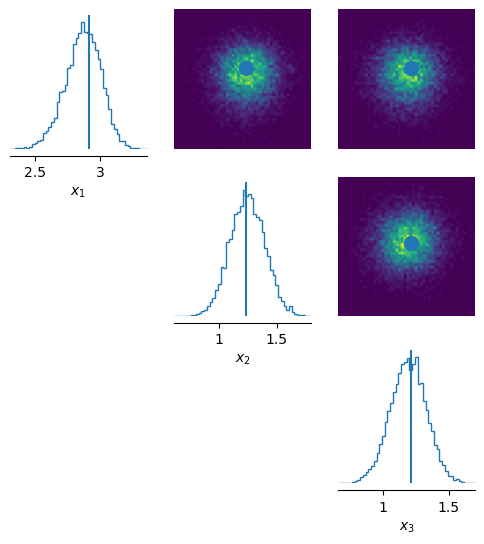

In [139]:
theta_posterior = posterior.sample((10000,), x=x_obs)  # sample from posterior
x_predictive = simulator(theta_posterior)  # simulate data from posterior
pairplot(x_predictive,
         points=x_obs, 
         figsize=(6, 6),
         labels=[r"$x_1$", r"$x_2$", r"$x_3$"]
        )